In [8]:
# ライブラリのインポート
import collections
from ortools.sat.python import cp_model

In [9]:
import pandas as pd

m = int(input("機械数を入力してください"))
n = int(input("ジョブ数を入力してください"))
s = input('ファイル名を入力してください')

df = pd.read_csv(f'./data/Benchmark/{s}.csv')
#df_t = pd.read_csv(f'/Users/kurozuhajime/Desktop/JSScheduling/data/Benchmark/opetime/{n}_{m}_py.csv')

ope_number = 0
jobs_data = []
for j in range(n):
    job = []
    for k in range(m):
        ope_number += 1
        idx_M = 'M_' + str(k+1)
        idx_T = 'P_' + str(k+1)
        kk = df[idx_M][j], df[idx_T][j]
        job.append(kk)
    jobs_data.append(job)
#jobs_data.append([])
print(ope_number)
print(jobs_data)


2000
[[(np.int64(9), np.int64(54)), (np.int64(12), np.int64(87)), (np.int64(4), np.int64(61)), (np.int64(7), np.int64(35)), (np.int64(16), np.int64(5)), (np.int64(0), np.int64(48)), (np.int64(1), np.int64(33)), (np.int64(18), np.int64(21)), (np.int64(17), np.int64(65)), (np.int64(5), np.int64(83)), (np.int64(14), np.int64(78)), (np.int64(11), np.int64(14)), (np.int64(8), np.int64(70)), (np.int64(10), np.int64(25)), (np.int64(3), np.int64(36)), (np.int64(15), np.int64(56)), (np.int64(13), np.int64(87)), (np.int64(2), np.int64(32)), (np.int64(19), np.int64(96)), (np.int64(6), np.int64(62))], [(np.int64(17), np.int64(68)), (np.int64(13), np.int64(15)), (np.int64(19), np.int64(22)), (np.int64(6), np.int64(53)), (np.int64(10), np.int64(33)), (np.int64(11), np.int64(61)), (np.int64(1), np.int64(73)), (np.int64(7), np.int64(63)), (np.int64(16), np.int64(96)), (np.int64(18), np.int64(61)), (np.int64(14), np.int64(88)), (np.int64(15), np.int64(86)), (np.int64(5), np.int64(53)), (np.int64(3), np

In [10]:
import pandas as pd

# Data.

"""
jobs_data = [  # task = (machine_id, processing_time).
    [(0, 3), (1, 2), (2, 2)],  # Job0
    [(0, 2), (2, 1), (1, 4)],  # Job1
    [(1, 4), (2, 3)],  # Job2
]
"""

machines_count = 1 + max(task[0] for job in jobs_data for task in job)
all_machines = range(machines_count)
# Computes horizon dynamically as the sum of all durations.
horizon = sum(task[1] for job in jobs_data for task in job)

# Create the model.
model = cp_model.CpModel()

# Named tuple to store information about created variables.
task_type = collections.namedtuple("task_type", "start end interval")
# Named tuple to manipulate solution information.
assigned_task_type = collections.namedtuple(
    "assigned_task_type", "start job index duration"
)

# Creates job intervals and add to the corresponding machine lists.
all_tasks = {}
machine_to_intervals = collections.defaultdict(list)

for job_id, job in enumerate(jobs_data):
    for task_id, task in enumerate(job):
        machine, duration = task
        suffix = f"_{job_id}_{task_id}"
        start_var = model.new_int_var(0, horizon, "start" + suffix)
        end_var = model.new_int_var(0, horizon, "end" + suffix)
        interval_var = model.new_interval_var(
            start_var, duration, end_var, "interval" + suffix
        )
        all_tasks[job_id, task_id] = task_type(
            start=start_var, end=end_var, interval=interval_var
        )
        machine_to_intervals[machine].append(interval_var)

# Create and add disjunctive constraints.
for machine in all_machines:
    model.add_no_overlap(machine_to_intervals[machine])

# Precedences inside a job.
for job_id, job in enumerate(jobs_data):
    for task_id in range(len(job) - 1):
        model.add(
            all_tasks[job_id, task_id + 1].start >= all_tasks[job_id, task_id].end
        )

# Makespan objective.
obj_var = model.new_int_var(0, horizon, "makespan")
model.add_max_equality(
    obj_var,
    [all_tasks[job_id, len(job) - 1].end for job_id, job in enumerate(jobs_data)],
)
model.minimize(obj_var)

# Creates the solver and solve.
solver = cp_model.CpSolver()
status = solver.solve(model)

if status == cp_model.OPTIMAL or status == cp_model.FEASIBLE:
    print("Solution:")
    # Create one list of assigned tasks per machine.
    assigned_jobs = collections.defaultdict(list)
    for job_id, job in enumerate(jobs_data):
        for task_id, task in enumerate(job):
            machine = task[0]
            assigned_jobs[machine].append(
                assigned_task_type(
                    start=solver.value(all_tasks[job_id, task_id].start),
                    job=job_id,
                    index=task_id,
                    duration=task[1],
                )
            )

    # Create per machine output lines.

    df1 = pd.DataFrame(0, index=range(ope_number), columns=['MC_No', 'Ope_No', 'JB_No', 'ST_T', 'ED_T'])
    i = 0

    output = ""
    for machine in all_machines:
        # Sort by starting time.
        assigned_jobs[machine].sort()
        sol_line_tasks = "Machine " + str(machine) + ": "
        sol_line = "           "

        ope_num = 0

        for assigned_task in assigned_jobs[machine]:

            df1['MC_No'][i] =  machine

            name = f"job_{assigned_task.job}_task_{assigned_task.index}"
            # add spaces to output to align columns.

            df1['Ope_No'][i] = ope_num
            ope_num += 1

            df1['JB_No'][i] = assigned_task.job

            sol_line_tasks += f"{name:15}"
            start = assigned_task.start
            duration = assigned_task.duration
            sol_tmp = f"[{start},{start + duration}]"
            # add spaces to output to align columns.

            df1['ST_T'][i] = start
            df1['ED_T'][i] = start + duration
            i += 1

            sol_line += f"{sol_tmp:15}"

        sol_line += "\n"
        sol_line_tasks += "\n"
        output += sol_line_tasks
        output += sol_line

    #print(df1)

    # Finally print the solution found.
    makespan = solver.objective_value
    print(f"Optimal Schedule Length: {makespan}")
    print(output)
else:
    print("No solution found.")

# Statistics.
print("\nStatistics")
print(f"  - conflicts: {solver.num_conflicts}")
print(f"  - branches : {solver.num_branches}")
print(f"  - wall time: {solver.wall_time}s")


Solution:
Optimal Schedule Length: 5183.0
Machine 0: job_56_task_0  job_44_task_1  job_94_task_0  job_12_task_1  job_92_task_3  job_53_task_2  job_9_task_3   job_19_task_3  job_50_task_2  job_36_task_2  job_83_task_5  job_35_task_7  job_14_task_2  job_59_task_3  job_0_task_5   job_4_task_6   job_85_task_2  job_82_task_3  job_70_task_6  job_75_task_2  job_43_task_5  job_17_task_3  job_90_task_3  job_84_task_4  job_62_task_7  job_2_task_7   job_71_task_8  job_76_task_6  job_45_task_9  job_27_task_8  job_91_task_10 job_22_task_9  job_31_task_3  job_77_task_8  job_25_task_6  job_63_task_6  job_23_task_8  job_96_task_6  job_28_task_8  job_34_task_14 job_46_task_9  job_86_task_10 job_18_task_8  job_10_task_11 job_57_task_10 job_7_task_8   job_67_task_8  job_61_task_8  job_33_task_13 job_32_task_9  job_41_task_14 job_40_task_10 job_58_task_15 job_8_task_13  job_68_task_16 job_39_task_13 job_97_task_11 job_11_task_15 job_66_task_11 job_88_task_14 job_60_task_16 job_99_task_14 job_42_task_13 jo

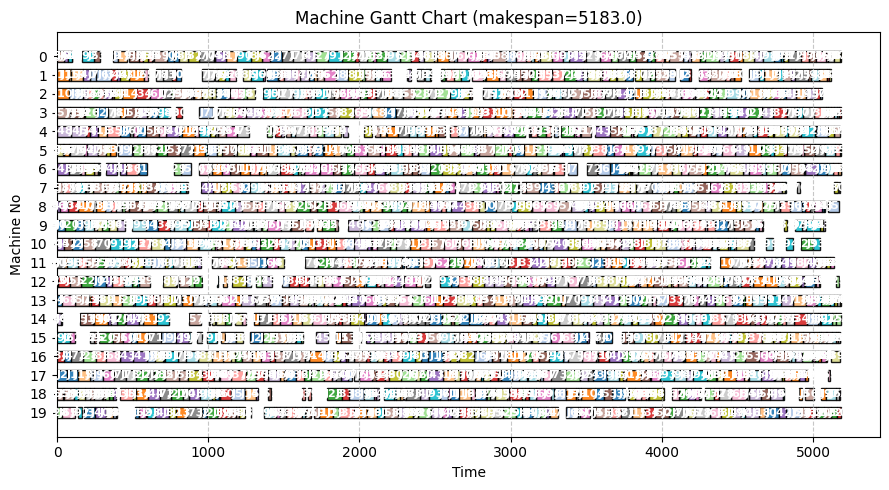

In [11]:
# import plotly.io as pio
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# -----------------------------------------------

# グラフのセットアップ
fig, ax = plt.subplots(figsize=(9, 5))

# ジョブごとに色を分けるための設定
unique_jobs = sorted(df1['JB_No'].unique())
# ジョブ数に応じたカラーマップを作成 (tab20は20色まで区別可能)
colors = cm.tab20(np.linspace(0, 1, len(unique_jobs)))
job_color_map = {job: color for job, color in zip(unique_jobs, colors)}

# マシンごとにグループ化するのではなく、ジョブごとにループしてプロットする
# (凡例をきれいに作成するため、および同じジョブを同じ色にするため)
for job_id in unique_jobs:
    # そのジョブのデータのみ抽出
    job_data = df1[df1['JB_No'] == job_id]

    # 横棒グラフ (barh) の描画
    # y: マシン番号, width: 所要時間(終了-開始), left: 開始時間
    ax.barh(
        y=job_data['MC_No'],
        width=job_data['ED_T'] - job_data['ST_T'],
        left=job_data['ST_T'],
        height=0.6,
        color=job_color_map[job_id],
        edgecolor='black', # 枠線
        label=f'Job {job_id}',
        align='center',
        alpha=0.9
    )

    # 棒の中にジョブ番号を表示（オプション）
    for _, row in job_data.iterrows():
        mid_point = row['ST_T'] + (row['ED_T'] - row['ST_T']) / 2
        ax.text(mid_point, row['MC_No'], f"J{int(row['JB_No'])}",
                ha='center', va='center', color='white', fontsize=8, fontweight='bold')

# 軸とタイトルの設定
ax.set_xlabel('Time')
ax.set_ylabel('Machine No')
ax.set_title(f'Machine Gantt Chart (makespan={makespan})')
ax.grid(True, axis='x', linestyle='--', alpha=0.7)

# マシン番号が整数の場合、Y軸目盛を整数に固定
all_machines = sorted(df1['MC_No'].unique())
ax.set_yticks(all_machines)

# Y軸を反転（通常ガントチャートは上から下へマシン番号が増えるため）
ax.invert_yaxis()

# 凡例の表示（グラフの外側に配置）
#ax.legend(title="Job No", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()





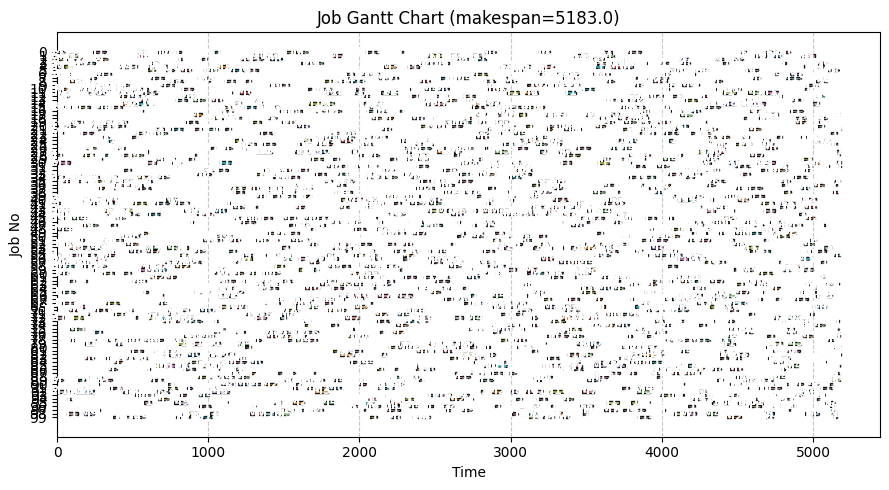

In [12]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import pandas as pd

# --- (前提) df1 が既に存在しているものとします ---

# グラフのセットアップ
fig, ax = plt.subplots(figsize=(9, 5))

# マシンごとに色を分ける設定（ジョブ別チャートなので、どの機械を使っているか色で区別します）
unique_machines = sorted(df1['MC_No'].unique())
# マシン数に応じたカラーマップを作成
colors = cm.tab20(np.linspace(0, 1, len(unique_machines)))
machine_color_map = {mc: color for mc, color in zip(unique_machines, colors)}

# マシンごとにループしてプロット（凡例をマシン名にするため）
for mc_id in unique_machines:
    # そのマシンのデータのみ抽出
    mc_data = df1[df1['MC_No'] == mc_id]

    # 横棒グラフ (barh) の描画
    # y: ジョブ番号, width: 所要時間, left: 開始時間
    ax.barh(
        y=mc_data['JB_No'],
        width=mc_data['ED_T'] - mc_data['ST_T'],
        left=mc_data['ST_T'],
        height=0.6,
        color=machine_color_map[mc_id],
        edgecolor='black',
        label=f'Machine {mc_id}', # 凡例はマシン名
        align='center',
        alpha=0.9
    )

# バーの中にマシン番号を表示
for _, row in df1.iterrows():
    mid_point = row['ST_T'] + (row['ED_T'] - row['ST_T']) / 2
    # バーの中に "M1" のように表示
    ax.text(mid_point, row['JB_No'], f"M{int(row['MC_No'])}",
            ha='center', va='center', color='white', fontsize=8, fontweight='bold')

# 軸とタイトルの設定
ax.set_xlabel('Time')
ax.set_ylabel('Job No')      # Y軸ラベルをJobに変更
ax.set_title(f'Job Gantt Chart (makespan={makespan})') # タイトル変更
ax.grid(True, axis='x', linestyle='--', alpha=0.7)

# ジョブ番号が整数の場合、Y軸目盛を整数に固定
all_jobs = sorted(df1['JB_No'].unique())
ax.set_yticks(all_jobs)

# Y軸を反転（Job 0, 1, 2... と上から順に並べるため）
ax.invert_yaxis()

# 凡例の表示（Machineごとの色）
#ax.legend(title="Machine No", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()
